# Climate-Action-GABM — Experiment Runner

Interactive notebook for configuring, running, and analysing simulations.

**Run 3 changes:**
- **Phase ordering fix:** P-A/P-B order now alternates by day (odd days: P-A→P-B, even days: P-B→P-A) to eliminate recency bias favouring whichever agent speaks last
- **LLM upgrade:** gpt-4o-mini → gpt-4.1-mini (better instruction following and reasoning, similar speed)
- **Scale:** 30 → 50 agents (more diverse sample, better statistical power)
- Temperature, days, policy, network, and seed unchanged for direct comparison with Runs 1-2

**Previous changes (Run 2):**
- Fix A: Removed previous-response anchoring from end-of-day survey prompt
- Fix B: Added reflection bridge ("Consider how today's messages have shaped your thinking")
- Fix C: Political agent prompts rewritten — Agent A = Green Party UK, Agent B = Reform UK

**Workflow:**
1. Configure experiment parameters
2. Load survey data and build nation
3. Run simulation
4. Inspect results (trajectories, reflections, shifts)
5. Visualise and save (figures exported to experiment output directory)

In [1]:
import sys, os, logging, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure src/ is on the path
sys.path.insert(0, os.path.abspath("../src"))

from cag.io.survey import load
from cag.abm.environment import SurveyedNation
from cag.abm.agent import SurveyedCitizen
from cag.abm.attributes.opinion import ClimatePolicyID
from cag.abm.sim import run_simulation, save_results, plot_opinion_trajectories, SIM_CONFIG
from cag.__main__ import build_nation

# ── Logging: show only our sim-level messages, silence HTTP noise ──
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
for _noisy in ("httpx", "openai", "urllib3", "httpcore"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)

sns.set_theme(style="whitegrid", font_scale=1.1)

print("Imports OK")

Imports OK


## 1. Experiment Configuration

Edit the `EXPERIMENT_CONFIG` dict below to define your experiment.

Key parameters:
- `n_citizens`: Number of agents to sample from the survey data
- `days`: List of day configs, each with a `policy` and `phases` (P-A, P-B, C)
- `k_peers_per_day`: Number of peers each agent exchanges messages with
- `p_intra` / `p_inter`: Within-block / between-block network connection probabilities
- `llm_model`: Which LLM to use (gpt-4o-mini is fast and cheap)
- `random_seed`: For reproducibility

In [2]:
# ── EDIT THIS CELL TO CONFIGURE YOUR EXPERIMENT ────────────

N_CITIZENS = 50
N_DAYS = 7
POLICY = ClimatePolicyID.BAN_PETROL_CARS  # most polarised policy — maximum sensitivity to persuasion

# Alternate phase ordering to eliminate recency bias:
#   Odd days  (1,3,5,7): P-A speaks first, P-B second
#   Even days (2,4,6):   P-B speaks first, P-A second
PHASES_ODD  = ["P-A", "P-B", "C"]
PHASES_EVEN = ["P-B", "P-A", "C"]

EXPERIMENT_CONFIG = {
    "n_citizens": N_CITIZENS,
    "days": [
        {"policy": POLICY, "phases": PHASES_ODD if (i + 1) % 2 == 1 else PHASES_EVEN}
        for i in range(N_DAYS)
    ],
    "k_peers_per_day": 3,
    "network_type": "stochastic_block",
    "p_intra": 0.15,
    "p_inter": 0.02,
    "llm_model": "gpt-4.1-mini",
    "llm_provider": "openai",
    "llm_temperature": 0.5,
    "random_seed": 42,
}

# ── Cost estimate ──────────────────────────────────────────
# With new exposure rules: ~77% of agents are A- or B-connected,
# ~49% are "both", ~5% are "neither" (no political messages).
a_connected = int(N_CITIZENS * 0.76)  # A-only + both ≈ 76%
b_connected = int(N_CITIZENS * 0.68)  # B-only + both ≈ 68%

calls_baseline = N_CITIZENS
calls_pa = 1 + a_connected                              # msg gen + reflections
calls_pb = 1 + b_connected                              # msg gen + reflections
calls_c = N_CITIZENS + N_CITIZENS                        # peer gen + receive
calls_survey = N_CITIZENS                                # end-of-day
calls_memory = N_CITIZENS                                # compression (days 3+)

calls_day_1_2 = calls_pa + calls_pb + calls_c + calls_survey           # no memory
calls_day_3_plus = calls_pa + calls_pb + calls_c + calls_survey + calls_memory
total_calls = calls_baseline + calls_day_1_2 * min(N_DAYS, 2) + calls_day_3_plus * max(N_DAYS - 2, 0)
est_cost = total_calls * 0.0008  # ~$0.0008 per gpt-4.1-mini call (rough)

print(f"Experiment: {N_CITIZENS} agents × {N_DAYS} days")
print(f"Policy: {POLICY}")
print(f"Model: {EXPERIMENT_CONFIG['llm_model']}")
print(f"Temperature: {EXPERIMENT_CONFIG['llm_temperature']}")
print(f"Phase ordering: alternating (odd=P-A first, even=P-B first)")
print(f"Estimated LLM calls: ~{total_calls:,}")
print(f"Estimated cost: ~${est_cost:.2f} ({EXPERIMENT_CONFIG['llm_model']})")

Experiment: 50 agents × 7 days
Policy: ClimatePolicyID(3)
Model: gpt-4.1-mini
Temperature: 0.5
Phase ordering: alternating (odd=P-A first, even=P-B first)
Estimated LLM calls: ~1,868
Estimated cost: ~$1.49 (gpt-4.1-mini)


## 2. Load Data and Build Nation

In [3]:
random.seed(EXPERIMENT_CONFIG["random_seed"])
np.random.seed(EXPERIMENT_CONFIG["random_seed"])

data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
data = data.sample(n=EXPERIMENT_CONFIG["n_citizens"],
                    random_state=EXPERIMENT_CONFIG["random_seed"])
print(f"Sampled {len(data)} citizens from survey data")

nation = build_nation(data)
print(f"Nation built: {len(nation.agents_active)} agents")

2026-04-17 20:42:12,520 [INFO] Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
2026-04-17 20:42:12,520 [INFO] Column with most NaNs: tprofile_gross_household (398 NaNs)
2026-04-17 20:42:12,524 [INFO] 1483 rows after filtering.


Sampled 50 citizens from survey data
Nation built: 50 agents


## 3. Run Simulation

This cell makes live LLM API calls. Review the config above before running.

In [4]:
results = run_simulation(EXPERIMENT_CONFIG, nation)
print(f"Simulation complete.")
print(f"Trajectories: {len(results['opinion_trajectories'])} rows")
print(f"Reflections: {len(results['reflections'])} rows")

2026-04-17 20:42:38,736 [INFO] Simulation: 50 agents, 7 days
2026-04-17 20:42:38,737 [INFO] Running baseline survey (day 0), policy=ClimatePolicyID(3)
2026-04-17 20:43:25,626 [INFO] --- Day 1/7 (policy=ClimatePolicyID(3), phases=['P-A', 'P-B', 'C']) ---
2026-04-17 20:45:11,098 [INFO] [P-A] Day 1: delivered message to 38 citizens. Message (first 120 chars): I strongly support the government’s policy to ban the sale of new petrol cars by 2030. This is a vital step towards tack...
2026-04-17 20:45:11,100 [INFO] [P-A] Sample reflection: Reading this message makes me appreciate the importance of tackling air pollution and climate change, especially since these issues affect our health and the future of our children. The idea of bannin...
2026-04-17 20:46:52,168 [INFO] [P-B] Day 1: delivered message to 36 citizens. Message (first 120 chars): Let’s be clear: banning the sale of new petrol cars by 2030 is a reckless, out-of-touch policy dreamed up by the Westmin...
2026-04-17 20:46:52,169 [INF

Simulation complete.
Trajectories: 400 rows
Reflections: 847 rows


In [5]:
# Save results
out_path = save_results(results, output_dir="../data/output/experiments")
print(f"Results saved to {out_path}")

2026-04-17 22:11:56,207 [INFO] Results saved to ../data/output/experiments/20260417_221156


Results saved to ../data/output/experiments/20260417_221156


## 4. Inspect Results

In [6]:
traj = results["opinion_trajectories"]
ref = results["reflections"]

print(f"Trajectory shape: {traj.shape}")
print(f"Unique agents: {traj['agent_id'].nunique()}")
print(f"Days recorded: {sorted(traj['day'].unique())}")
print(f"Policies: {traj['policy_id'].unique()}")
print()
display(traj.head(10))

Trajectory shape: (400, 4)
Unique agents: 50
Days recorded: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Policies: <StringArray>
['ClimatePolicyID(3)']
Length: 1, dtype: str



,agent_id,day,policy_id,numeric
0,165.0,0,ClimatePolicyID(3),2
1,165.0,1,ClimatePolicyID(3),-1
2,165.0,2,ClimatePolicyID(3),2
3,165.0,3,ClimatePolicyID(3),-2
4,165.0,4,ClimatePolicyID(3),2
5,165.0,5,ClimatePolicyID(3),2
6,165.0,6,ClimatePolicyID(3),2
7,165.0,7,ClimatePolicyID(3),2
8,582.0,0,ClimatePolicyID(3),2
9,582.0,1,ClimatePolicyID(3),2


In [7]:
# ── Per-day summary statistics ─────────────────────────────
day_stats = traj.groupby("day")["numeric"].agg(["mean", "std", "min", "max", "count"])
day_stats.columns = ["Mean", "SD", "Min", "Max", "N"]
display(day_stats.round(2))

,Mean,SD,Min,Max,N
day,,,,,
0,1.96,1.03,-2,3,50
1,1.52,1.33,-2,3,50
2,1.40,1.50,-2,3,50
3,1.14,1.64,-2,3,50
4,1.16,1.61,-2,3,50
5,1.18,1.65,-2,3,50
6,1.18,1.66,-2,3,50
7,1.12,1.73,-2,3,50


In [8]:
# ── Shift analysis: day-over-day opinion changes ───────────
# Compute shifts for the target policy
policy_traj = traj[traj["policy_id"] == str(POLICY)].copy()
policy_traj = policy_traj.sort_values(["agent_id", "day"])
policy_traj["prev"] = policy_traj.groupby("agent_id")["numeric"].shift(1)
policy_traj["shift"] = policy_traj["numeric"] - policy_traj["prev"]

shifts = policy_traj.dropna(subset=["shift"])

print(f"Total day-over-day observations: {len(shifts)}")
print(f"Mean shift: {shifts['shift'].mean():+.3f}")
print(f"SD of shifts: {shifts['shift'].std():.3f}")
print(f"% with zero shift: {(shifts['shift'] == 0).mean():.1%}")
print()
print("Shift distribution:")
display(shifts["shift"].value_counts().sort_index().to_frame("count"))

Total day-over-day observations: 350
Mean shift: -0.120
SD of shifts: 0.855
% with zero shift: 84.9%

Shift distribution:


,count
shift,
-4.0,5
-3.0,8
-2.0,2
-1.0,23
0.0,297
1.0,9
3.0,4
4.0,2


In [9]:
# ── Which agents moved the most? ──────────────────────────
agent_range = policy_traj.groupby("agent_id")["numeric"].agg(["first", "last", "min", "max"])
agent_range["total_shift"] = agent_range["last"] - agent_range["first"]
agent_range["range"] = agent_range["max"] - agent_range["min"]
agent_range = agent_range.sort_values("total_shift")

print("Top movers (by total shift from baseline):")
display(agent_range.head(5))
print()
display(agent_range.tail(5))

Top movers (by total shift from baseline):


,first,last,min,max,total_shift,range
agent_id,,,,,,
1833.0,2,-2,-2,2,-4,4
1454.0,2,-2,-2,2,-4,4
381.0,2,-2,-2,2,-4,4
1343.0,2,-2,-2,2,-4,4
1065.0,2,-2,-2,2,-4,4


,first,last,min,max,total_shift,range
agent_id,,,,,,
1904.0,2,2,-1,2,0,3
828.0,2,2,2,2,0,0
424.0,2,2,2,2,0,0
1957.0,2,2,2,2,0,0
1269.0,2,3,2,3,1,1


In [10]:
# ── Reflections overview ───────────────────────────────────
print(f"Total reflections: {len(ref)}")
print(f"\nBy phase:")
display(ref["phase"].value_counts().to_frame("count"))
print(f"\nBy day:")
display(ref.groupby("day").size().to_frame("reflections"))

Total reflections: 847

By phase:


,count
phase,
C,329
P-A,266
P-B,252



By day:


,reflections
day,
1,122
2,118
3,121
4,122
5,122
6,122
7,120


## 5. Visualisation

All figures are saved to the experiment output directory alongside the CSV data.

2026-04-17 22:12:22,991 [INFO] Plot saved to ../data/output/experiments/20260417_221156/fig_trajectories.png


Saved → ../data/output/experiments/20260417_221156/fig_trajectories.png


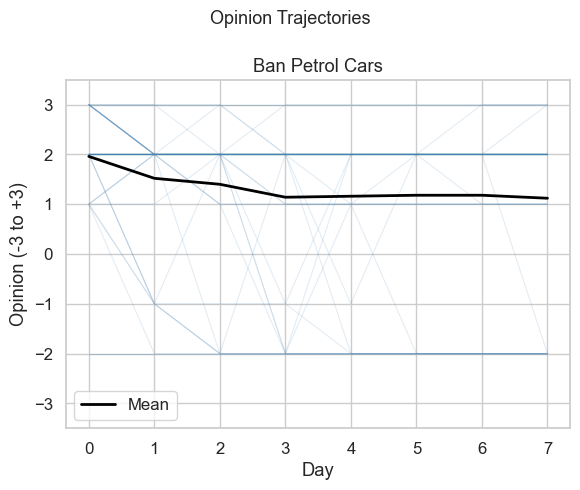

In [11]:
# ── Opinion trajectories (all agents + mean) ──────────────
fig_traj = plot_opinion_trajectories(results, output_path=out_path / "fig_trajectories.png")
print(f"Saved → {out_path / 'fig_trajectories.png'}")

Saved → ../data/output/experiments/20260417_221156/fig_trajectories_by_exposure.png


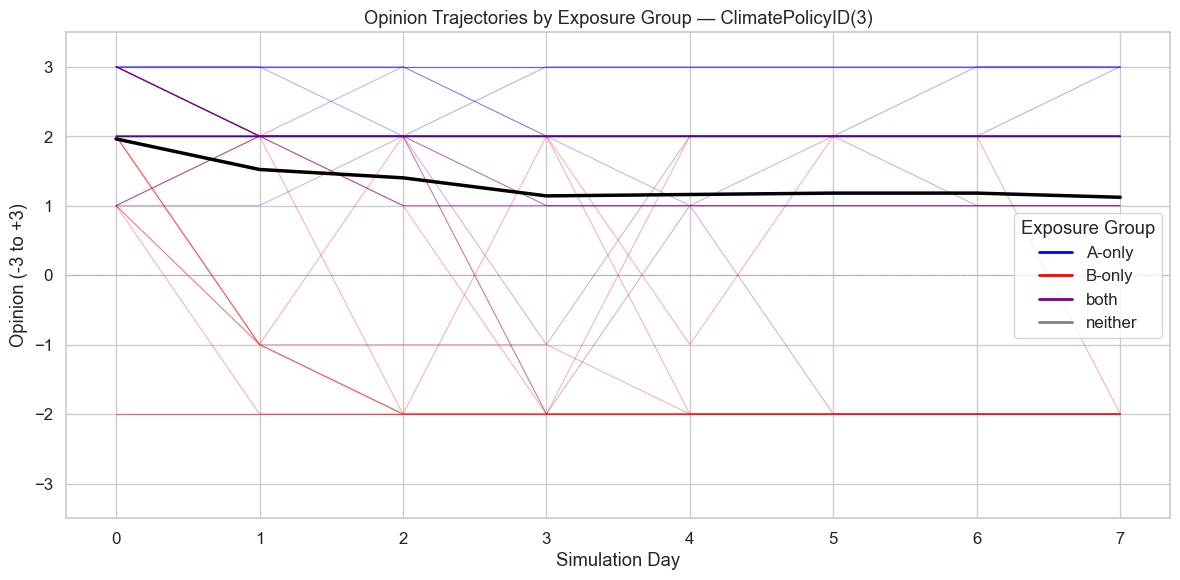

In [12]:
# ── Trajectory spaghetti plot with exposure groups ────────
fig, ax = plt.subplots(figsize=(12, 6))

exposure_colors = {"A-only": "blue", "B-only": "red", "both": "purple", "neither": "grey"}

for agent in nation.agents_active.values():
    history = agent.opinion_history.get(POLICY, [])
    if not history:
        continue
    days_list, opinions = zip(*history)
    color = exposure_colors.get(agent.political_exposure, "grey")
    ax.plot(days_list, opinions, alpha=0.3, color=color, linewidth=0.8)

# Legend
from matplotlib.lines import Line2D
legend_lines = [Line2D([0], [0], color=c, linewidth=2, label=l) for l, c in exposure_colors.items()]
ax.legend(handles=legend_lines, title="Exposure Group")

# Mean trajectory
if not policy_traj.empty:
    mean_traj = policy_traj.groupby("day")["numeric"].mean()
    ax.plot(mean_traj.index, mean_traj.values, color="black", linewidth=2.5, label="Mean")

ax.set_xlabel("Simulation Day")
ax.set_ylabel("Opinion (-3 to +3)")
ax.set_ylim(-3.5, 3.5)
ax.set_title(f"Opinion Trajectories by Exposure Group — {POLICY}")
ax.axhline(0, color="grey", ls=":", linewidth=0.5)
plt.tight_layout()
fig.savefig(out_path / "fig_trajectories_by_exposure.png", dpi=150, bbox_inches="tight")
print(f"Saved → {out_path / 'fig_trajectories_by_exposure.png'}")
plt.show()

Saved → ../data/output/experiments/20260417_221156/fig_mean_by_exposure.png


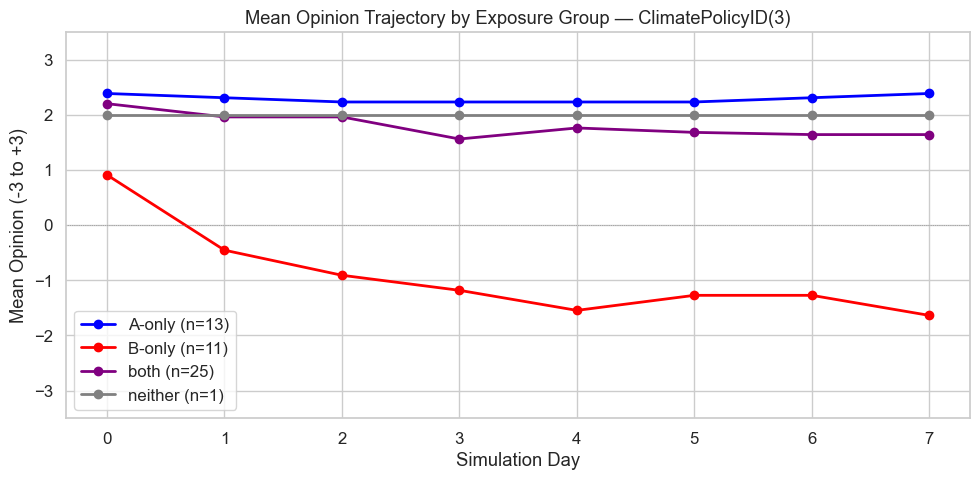

In [13]:
# ── Mean trajectory by exposure group ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Build exposure lookup
exposure_lookup = {agent.id: agent.political_exposure for agent in nation.agents_active.values()}
policy_traj_exp = policy_traj.copy()
policy_traj_exp["exposure"] = policy_traj_exp["agent_id"].map(exposure_lookup)

for group, color in exposure_colors.items():
    grp = policy_traj_exp[policy_traj_exp["exposure"] == group]
    if grp.empty:
        continue
    mean = grp.groupby("day")["numeric"].mean()
    n = grp["agent_id"].nunique()
    ax.plot(mean.index, mean.values, marker="o", linewidth=2, color=color, label=f"{group} (n={n})")

ax.axhline(0, color="grey", ls=":", linewidth=0.5)
ax.set_xlabel("Simulation Day")
ax.set_ylabel("Mean Opinion (-3 to +3)")
ax.set_ylim(-3.5, 3.5)
ax.set_title(f"Mean Opinion Trajectory by Exposure Group — {POLICY}")
ax.legend()
plt.tight_layout()
fig.savefig(out_path / "fig_mean_by_exposure.png", dpi=150, bbox_inches="tight")
print(f"Saved → {out_path / 'fig_mean_by_exposure.png'}")
plt.show()

Saved → ../data/output/experiments/20260417_221156/fig_distribution_baseline_vs_final.png


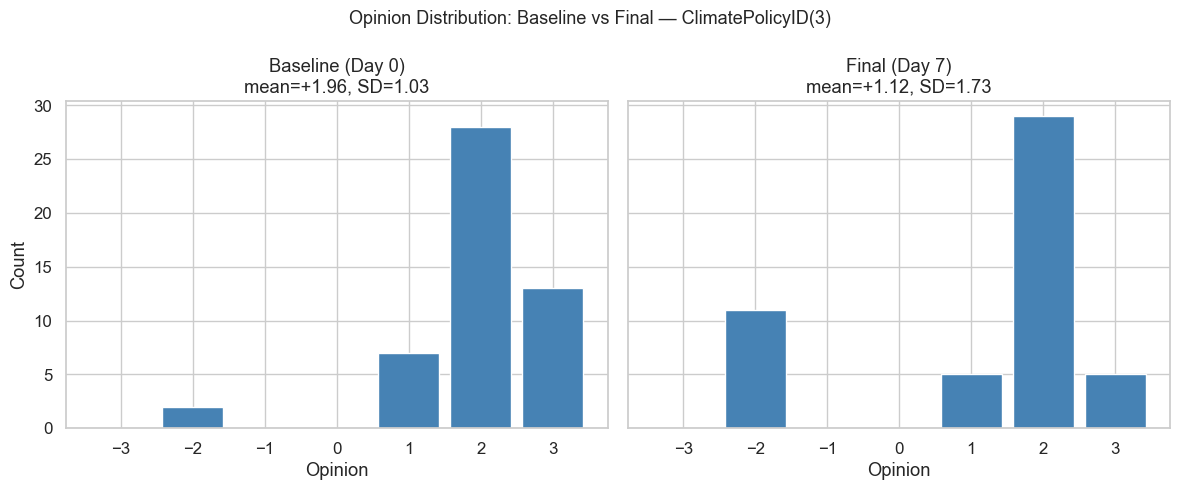

In [14]:
# ── Opinion distribution at baseline vs final day ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

day_0 = policy_traj[policy_traj["day"] == 0]["numeric"]
day_last = policy_traj[policy_traj["day"] == policy_traj["day"].max()]["numeric"]

for ax, data_col, title in [(axes[0], day_0, "Baseline (Day 0)"),
                             (axes[1], day_last, f"Final (Day {policy_traj['day'].max()})")]:
    data_col.hist(bins=np.arange(-3.5, 4.5, 1), ax=ax, color="steelblue", edgecolor="white", rwidth=0.85)
    ax.set_xticks(range(-3, 4))
    ax.set_xlabel("Opinion")
    ax.set_title(f"{title}\nmean={data_col.mean():+.2f}, SD={data_col.std():.2f}")

axes[0].set_ylabel("Count")
fig.suptitle(f"Opinion Distribution: Baseline vs Final — {POLICY}", fontsize=13)
plt.tight_layout()
fig.savefig(out_path / "fig_distribution_baseline_vs_final.png", dpi=150, bbox_inches="tight")
print(f"Saved → {out_path / 'fig_distribution_baseline_vs_final.png'}")
plt.show()

## 6. Sample Reflections

Inspect a few reflections to understand what agents are "thinking".

In [15]:
# Show reflections for the agent with the largest total shift
if len(agent_range) > 0:
    biggest_mover_id = agent_range["total_shift"].abs().idxmax()
    mover_refs = ref[ref["agent_id"] == biggest_mover_id].sort_values("day")
    print(f"=== Reflections for Agent {biggest_mover_id} (total shift = {agent_range.loc[biggest_mover_id, 'total_shift']:+d}) ===")
    print()
    for _, row in mover_refs.iterrows():
        print(f"Day {row['day']}, Phase {row['phase']}:")
        print(f"  {row['text'][:300]}...")
        print()

=== Reflections for Agent 1833.0 (total shift = -4) ===

Day 1, Phase P-A:
  Hearing this message makes me think more about the practical side of banning petrol cars by 2030. I can see the benefits of reducing pollution and helping the environment, which is important for everyone's health and future. But I also wonder about how affordable electric vehicles really are for wor...

Day 1, Phase P-B:
  This message really highlights some of the practical concerns I’ve been thinking about. It’s true that petrol cars are vital for many people outside big cities like where I live, and the upfront costs of electric vehicles do seem quite high. I hadn’t fully considered how this might hit rural communi...

Day 2, Phase P-B:
  This message really emphasizes the practical challenges and costs that a ban on petrol cars might impose on people like me, living outside big cities in the East of England. It reminds me that many working families and small businesses depend on petrol cars and that switch